In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
import joblib

# -----------------------------
# CARGA Y PREPROCESAMIENTO
# -----------------------------

# Cargar el dataset
df = pd.read_csv("covtype.data")
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [ ]:
columnas_cuantitativas = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

columnas_wilderness = [f'Wilderness_Area_{i}' for i in range(1, 5)]

columnas_soil = [f'Soil_Type_{i}' for i in range(1, 41)]

columna_target = ['Cover_Type']

todas_columnas = columnas_cuantitativas + columnas_wilderness + columnas_soil + columna_target

df.columns = todas_columnas

In [ ]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [ ]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
import joblib

# -----------------------------
# CARGA Y PREPROCESAMIENTO
# -----------------------------


# Columnas numéricas continuas que deben escalarse
columnas_cuantitativas = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                          'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                          'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                          'Horizontal_Distance_To_Fire_Points']

# Separar X e y
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Aplicar SMOTE para balancear clases en el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# -----------------------------
# PREPROCESADOR
# -----------------------------

# Escalador solo para columnas cuantitativas
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), columnas_cuantitativas)
    ],
    remainder='passthrough'  # Deja las demás columnas sin tocar (como las binarias)
)


# Definir el modelo base
rf_model = RandomForestClassifier(random_state=42)

# Pipeline para grid search
pipe_cv = Pipeline([
    ('preprocessing', preprocessor),
    ('model', rf_model)
])

# -----------------------------
# ENTRENAMIENTO FINAL
# -----------------------------

# Pipeline final con mejores hiperparámetros
final_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ))
])

# Entrenar pipeline final
final_pipeline.fit(X_train_resampled, y_train_resampled)

# Evaluar sobre conjunto de prueba
y_pred = final_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Precisión en el conjunto de prueba: {accuracy:.4f}")

# -----------------------------
# GUARDAR PIPELINE
# -----------------------------

joblib.dump(final_pipeline, 'modelo_pipeline.pkl')
print("✅ Pipeline completo guardado como 'modelo_pipeline.pkl'")


🎯 Precisión en el conjunto de prueba: 0.9593
✅ Pipeline completo guardado como 'modelo_pipeline.pkl'


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.9593


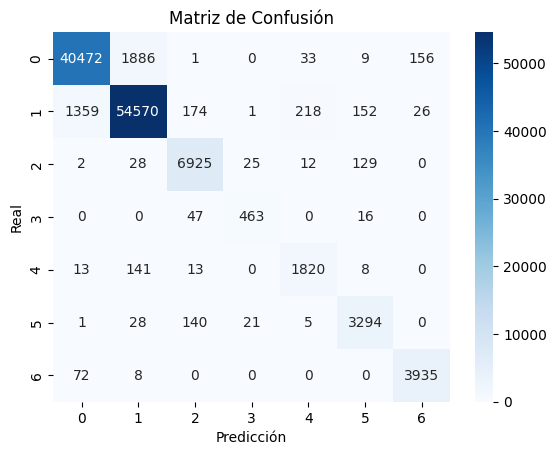

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.97      0.95      0.96     42557
           2       0.96      0.97      0.96     56500
           3       0.95      0.97      0.96      7121
           4       0.91      0.88      0.89       526
           5       0.87      0.91      0.89      1995
           6       0.91      0.94      0.93      3489
           7       0.96      0.98      0.97      4015

    accuracy                           0.96    116203
   macro avg       0.93      0.94      0.94    116203
weighted avg       0.96      0.96      0.96    116203



In [ ]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.4f}")


Cohen's Kappa: 0.9349


In [ ]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.4f}")


Balanced Accuracy: 0.9437


=== Métricas en entrenamiento ===
Accuracy: 1.0000
Balanced Accuracy: 1.0000
Cohen's Kappa: 1.0000

=== Métricas en prueba ===
Accuracy: 0.9593
Balanced Accuracy: 0.9437
Cohen's Kappa: 0.9349

=== Reporte clasificación en test ===
              precision    recall  f1-score   support

           1       0.97      0.95      0.96     42557
           2       0.96      0.97      0.96     56500
           3       0.95      0.97      0.96      7121
           4       0.91      0.88      0.89       526
           5       0.87      0.91      0.89      1995
           6       0.91      0.94      0.93      3489
           7       0.96      0.98      0.97      4015

    accuracy                           0.96    116203
   macro avg       0.93      0.94      0.94    116203
weighted avg       0.96      0.96      0.96    116203



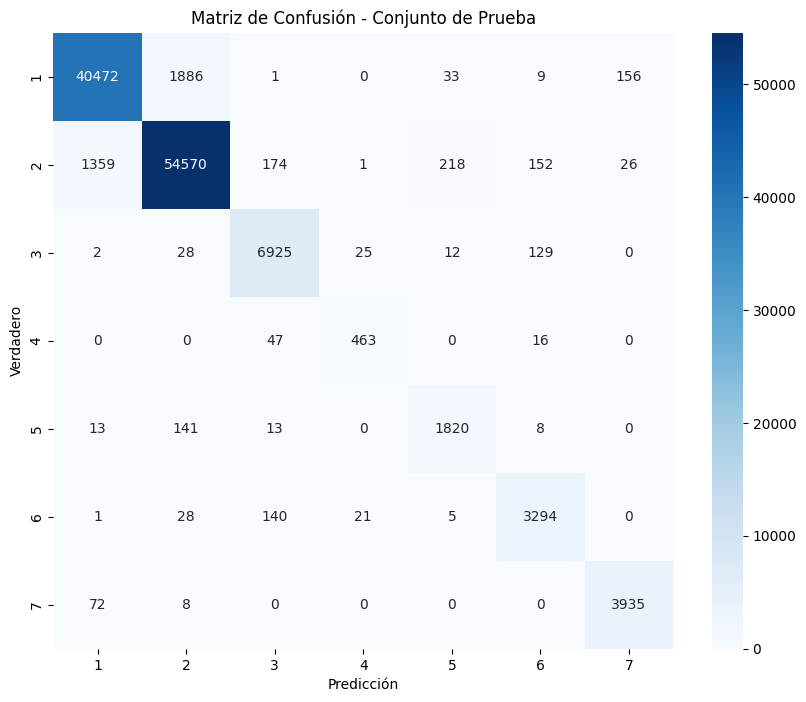

✅ No parece haber overfitting significativo.


In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, cohen_kappa_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones en conjunto de entrenamiento
y_train_pred = final_pipeline.predict(X_train)
# Predicciones en conjunto de prueba
y_test_pred = final_pipeline.predict(X_test)

# Métricas para entrenamiento
acc_train = accuracy_score(y_train, y_train_pred)
bal_acc_train = balanced_accuracy_score(y_train, y_train_pred)
kappa_train = cohen_kappa_score(y_train, y_train_pred)

# Métricas para prueba
acc_test = accuracy_score(y_test, y_test_pred)
bal_acc_test = balanced_accuracy_score(y_test, y_test_pred)
kappa_test = cohen_kappa_score(y_test, y_test_pred)

print("=== Métricas en entrenamiento ===")
print(f"Accuracy: {acc_train:.4f}")
print(f"Balanced Accuracy: {bal_acc_train:.4f}")
print(f"Cohen's Kappa: {kappa_train:.4f}\n")

print("=== Métricas en prueba ===")
print(f"Accuracy: {acc_test:.4f}")
print(f"Balanced Accuracy: {bal_acc_test:.4f}")
print(f"Cohen's Kappa: {kappa_test:.4f}\n")

# Reporte clasificación (test)
print("=== Reporte clasificación en test ===")
print(classification_report(y_test, y_test_pred))

# Matriz de confusión (test)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.title("Matriz de Confusión - Conjunto de Prueba")
plt.show()

# Análisis básico de overfitting
if acc_train - acc_test > 0.05:
    print("⚠️ Posible overfitting: la precisión en entrenamiento es mucho mayor que en prueba.")
else:
    print("✅ No parece haber overfitting significativo.")


Variables usadas en el modelo:
Elevation
Aspect
Slope
Horizontal_Distance_To_Hydrology
Vertical_Distance_To_Hydrology
Horizontal_Distance_To_Roadways
Hillshade_9am
Hillshade_Noon
Hillshade_3pm
Horizontal_Distance_To_Fire_Points
Wilderness_Area_1
Wilderness_Area_2
Wilderness_Area_3
Wilderness_Area_4
Soil_Type_1
Soil_Type_2
Soil_Type_3
Soil_Type_4
Soil_Type_5
Soil_Type_6
Soil_Type_7
Soil_Type_8
Soil_Type_9
Soil_Type_10
Soil_Type_11
Soil_Type_12
Soil_Type_13
Soil_Type_14
Soil_Type_15
Soil_Type_16
Soil_Type_17
Soil_Type_18
Soil_Type_19
Soil_Type_20
Soil_Type_21
Soil_Type_22
Soil_Type_23
Soil_Type_24
Soil_Type_25
Soil_Type_26
Soil_Type_27
Soil_Type_28
Soil_Type_29
Soil_Type_30
Soil_Type_31
Soil_Type_32
Soil_Type_33
Soil_Type_34
Soil_Type_35
Soil_Type_36
Soil_Type_37
Soil_Type_38
Soil_Type_39
Soil_Type_40


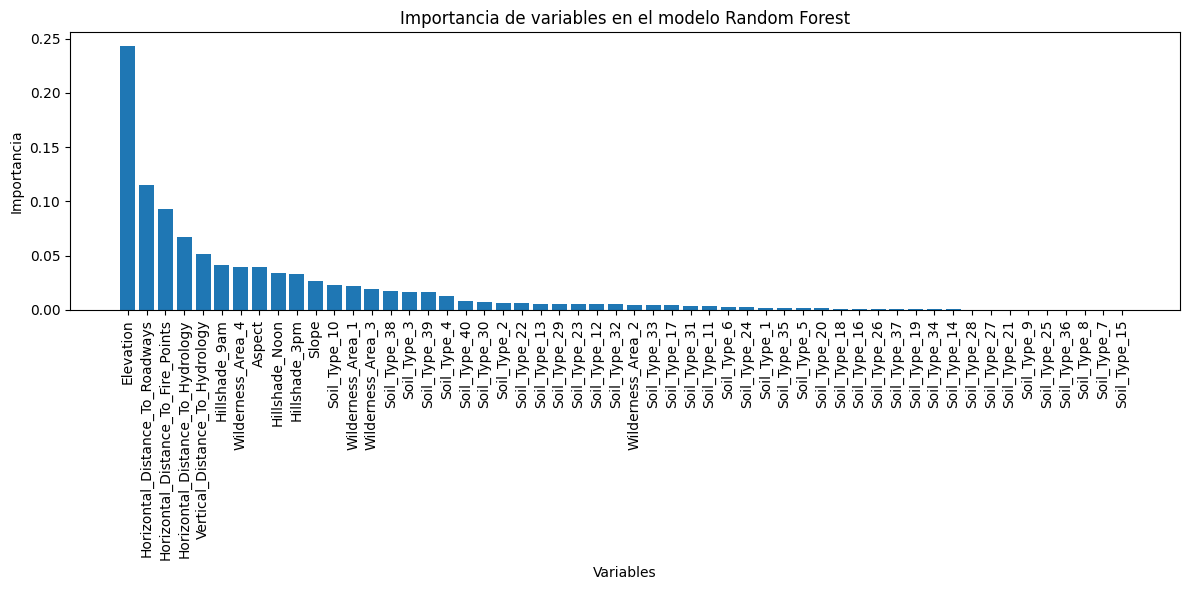

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Obtener las columnas que entraron al modelo (después del preprocesamiento)
# 1. Variables cuantitativas (las que pasaron por StandardScaler)
quantitative_features = final_pipeline.named_steps['preprocessing'].transformers_[0][2]

# 2. Variables restantes que pasaron tal cual (passthrough)
# El preprocesador deja pasar las demás columnas (binarias)
passthrough_features = list(df.drop(columns=quantitative_features + ['Cover_Type']).columns)

# Concatenamos todas las columnas que entran al modelo
features = list(quantitative_features) + passthrough_features

print("Variables usadas en el modelo:")
for f in features:
    print(f)

# Obtener importancias del Random Forest
importances = final_pipeline.named_steps['model'].feature_importances_

# Crear gráfico de importancias
plt.figure(figsize=(12, 6))
indices = np.argsort(importances)[::-1]  # ordenar de mayor a menor

plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=90)
plt.xlabel('Variables')
plt.ylabel('Importancia')
plt.title('Importancia de variables en el modelo Random Forest')
plt.tight_layout()
plt.show()
